In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [5]:
df = pd.read_csv('attendance.csv')

In [4]:
df_clean = df[(df['Total'] > 0)].copy()


In [14]:
features = ['DBMS', 'TOC', 'SPOS', 'CNS', 'IOT', 'DBMSL', 'CSNL', 'LPI']

In [15]:
X = df_clean[features].values  
y = df_clean['Total'].values 

In [16]:
correlation_df = df_clean[features + ['Total']].corr()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining set: {len(X_train)} students")
print(f"Testing set: {len(X_test)} students")


Training set: 60 students
Testing set: 15 students


In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
coefficients = model.coef_
intercept = model.intercept_
print(f"\nIntercept (b): {intercept:.4f}")
print("\nCoefficients (weights for each feature):")
print("-" * 50)
for feature, coef in zip(features, coefficients):
    print(f"{feature:10} : {coef:8.4f}")


Intercept (b): 0.0000

Coefficients (weights for each feature):
--------------------------------------------------
DBMS       :   1.0000
TOC        :   1.0000
SPOS       :   1.0000
CNS        :   1.0000
IOT        :   1.0000
DBMSL      :   1.0000
CSNL       :   1.0000
LPI        :   1.0000


In [25]:
equation = f"\nTotal = {intercept:.3f}"
for feature, coef in zip(features, coefficients):
    sign = "+" if coef >= 0 else ""
    equation += f" {sign} {coef:.3f}×{feature}"

print(equation)

print("\n💡 What this means:")
print(f"   - For every 1 day increase in DBMS, Total increases by {coefficients[0]:.3f}")
print(f"   - For every 1 day increase in TOC, Total increases by {coefficients[1]:.3f}")
print("   - And so on for each subject...")


Total = 0.000 + 1.000×DBMS + 1.000×TOC + 1.000×SPOS + 1.000×CNS + 1.000×IOT + 1.000×DBMSL + 1.000×CSNL + 1.000×LPI

💡 What this means:
   - For every 1 day increase in DBMS, Total increases by 1.000
   - For every 1 day increase in TOC, Total increases by 1.000
   - And so on for each subject...


In [28]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
print("\nPredictions on Test Set (First 10):")
print("-" * 70)
print(f"{'DBMS':<6} {'TOC':<6} {'SPOS':<6} {'CNS':<6} {'IOT':<6} | {'Actual':<8} {'Predicted':<10} {'Error'}")
print("-" * 70)

for i in range(min(10, len(X_test))):
    error = abs(y_test[i] - y_test_pred[i])
    print(f"{X_test[i][0]:4.0f}   {X_test[i][1]:4.0f}   {X_test[i][2]:4.0f}   "
          f"{X_test[i][3]:4.0f}   {X_test[i][4]:4.0f}   | "
          f"{y_test[i]:6.0f}    {y_test_pred[i]:8.1f}    {error:5.1f}")


Predictions on Test Set (First 10):
----------------------------------------------------------------------
DBMS   TOC    SPOS   CNS    IOT    | Actual   Predicted  Error
----------------------------------------------------------------------
  12     19      7     17     15   |     90        90.0      0.0
  10     13      3      9     10   |     56        56.0      0.0
  11     17      5     12      9   |     66        66.0      0.0
  10     10      4     10     11   |     50        50.0      0.0
  12     12      4     14      8   |     62        62.0      0.0
   0      2      0      0      1   |      4         4.0      0.0
  14     19      9     16     16   |     96        96.0      0.0
  12     12      6     11      8   |     63        63.0      0.0
   6      9      3      8      9   |     41        41.0      0.0
  14     15     10     15     14   |     82        82.0      0.0


In [31]:
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)

In [32]:
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)

In [33]:
print("\n📊 Training Set Performance:")
print(f"   R² Score: {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"   RMSE: {rmse_train:.2f} days")
print(f"   MAE: {mae_train:.2f} days")

print("\n📊 Test Set Performance:")
print(f"   R² Score: {r2_test:.4f} ({r2_test*100:.2f}%)")
print(f"   RMSE: {rmse_test:.2f} days")
print(f"   MAE: {mae_test:.2f} days")

print("\n💡 What these metrics mean:")
print(f"   R² = {r2_test*100:.1f}% of variance in Total is explained by the features")
print(f"   RMSE = On average, predictions are off by {rmse_test:.1f} days")
print(f"   MAE = Typical prediction error is {mae_test:.1f} days")

# Check for overfitting
print("\n🔍 Overfitting Check:")
if abs(r2_train - r2_test) < 0.1:
    print("   ✅ Good! Model generalizes well (no overfitting)")
else:
    print("   ⚠️ Warning! Large difference between train and test scores")


📊 Training Set Performance:
   R² Score: 1.0000 (100.00%)
   RMSE: 0.00 days
   MAE: 0.00 days

📊 Test Set Performance:
   R² Score: 1.0000 (100.00%)
   RMSE: 0.00 days
   MAE: 0.00 days

💡 What these metrics mean:
   R² = 100.0% of variance in Total is explained by the features
   RMSE = On average, predictions are off by 0.0 days
   MAE = Typical prediction error is 0.0 days

🔍 Overfitting Check:
   ✅ Good! Model generalizes well (no overfitting)


In [35]:
fig  = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3,3, hspace=0.3, wspace=0.3)

<Figure size 1600x1000 with 0 Axes>

In [36]:
fig.suptitle('Multiple Linear Regression Analysis', fontsize=16, fontweight='bold')

Text(0.5, 0.98, 'Multiple Linear Regression Analysis')

In [39]:
X_simple = df_clean[['DBMS']].values
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train_simple)
y_pred_simple = model_simple.predict(X_test_simple)

r2_simple = r2_score(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test_simple, y_pred_simple))

print("\n📊 Simple Linear Regression (DBMS only):")
print(f"   R² Score: {r2_simple:.4f} ({r2_simple*100:.2f}%)")
print(f"   RMSE: {rmse_simple:.2f} days")

print("\n📊 Multiple Linear Regression (All features):")
print(f"   R² Score: {r2_test:.4f} ({r2_test*100:.2f}%)")
print(f"   RMSE: {rmse_test:.2f} days")

print("\n🎯 Improvement:")
improvement = ((r2_test - r2_simple) / r2_simple) * 100
print(f"   R² improved by: {improvement:.1f}%")
print(f"   RMSE reduced by: {rmse_simple - rmse_test:.2f} days")

if r2_test > r2_simple:
    print("\n✅ Multiple regression performs BETTER!")
else:
    print("\n⚠️ Simple regression was sufficient")

# ============================================
# STEP 9: Feature Importance
# ============================================
print("\n" + "=" * 70)
print("STEP 9: Feature Importance Analysis")
print("=" * 70)

# Get absolute coefficients for importance
importance = np.abs(coefficients)
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Abs_Coefficient': importance
}).sort_values('Abs_Coefficient', ascending=False)

print("\nMost Important Features (by coefficient magnitude):")
print("-" * 50)
for idx, row in feature_importance.iterrows():
    bars = "█" * int(row['Abs_Coefficient'] * 3)
    print(f"{row['Feature']:10} : {row['Coefficient']:7.3f} {bars}")

print("\n💡 Interpretation:")
print("   Larger coefficient = More impact on Total attendance")
print(f"   Most important: {feature_importance.iloc[0]['Feature']}")
print(f"   Least important: {feature_importance.iloc[-1]['Feature']}")


📊 Simple Linear Regression (DBMS only):
   R² Score: 0.8423 (84.23%)
   RMSE: 9.46 days

📊 Multiple Linear Regression (All features):
   R² Score: 1.0000 (100.00%)
   RMSE: 0.00 days

🎯 Improvement:
   R² improved by: 18.7%
   RMSE reduced by: 9.46 days

✅ Multiple regression performs BETTER!

STEP 9: Feature Importance Analysis

Most Important Features (by coefficient magnitude):
--------------------------------------------------
CNS        :   1.000 ███
SPOS       :   1.000 ███
CSNL       :   1.000 ███
DBMSL      :   1.000 ███
IOT        :   1.000 ██
LPI        :   1.000 ██
TOC        :   1.000 ██
DBMS       :   1.000 ██

💡 Interpretation:
   Larger coefficient = More impact on Total attendance
   Most important: CNS
   Least important: DBMS



✅ Visualization saved as 'multiple_regression_analysis.png'


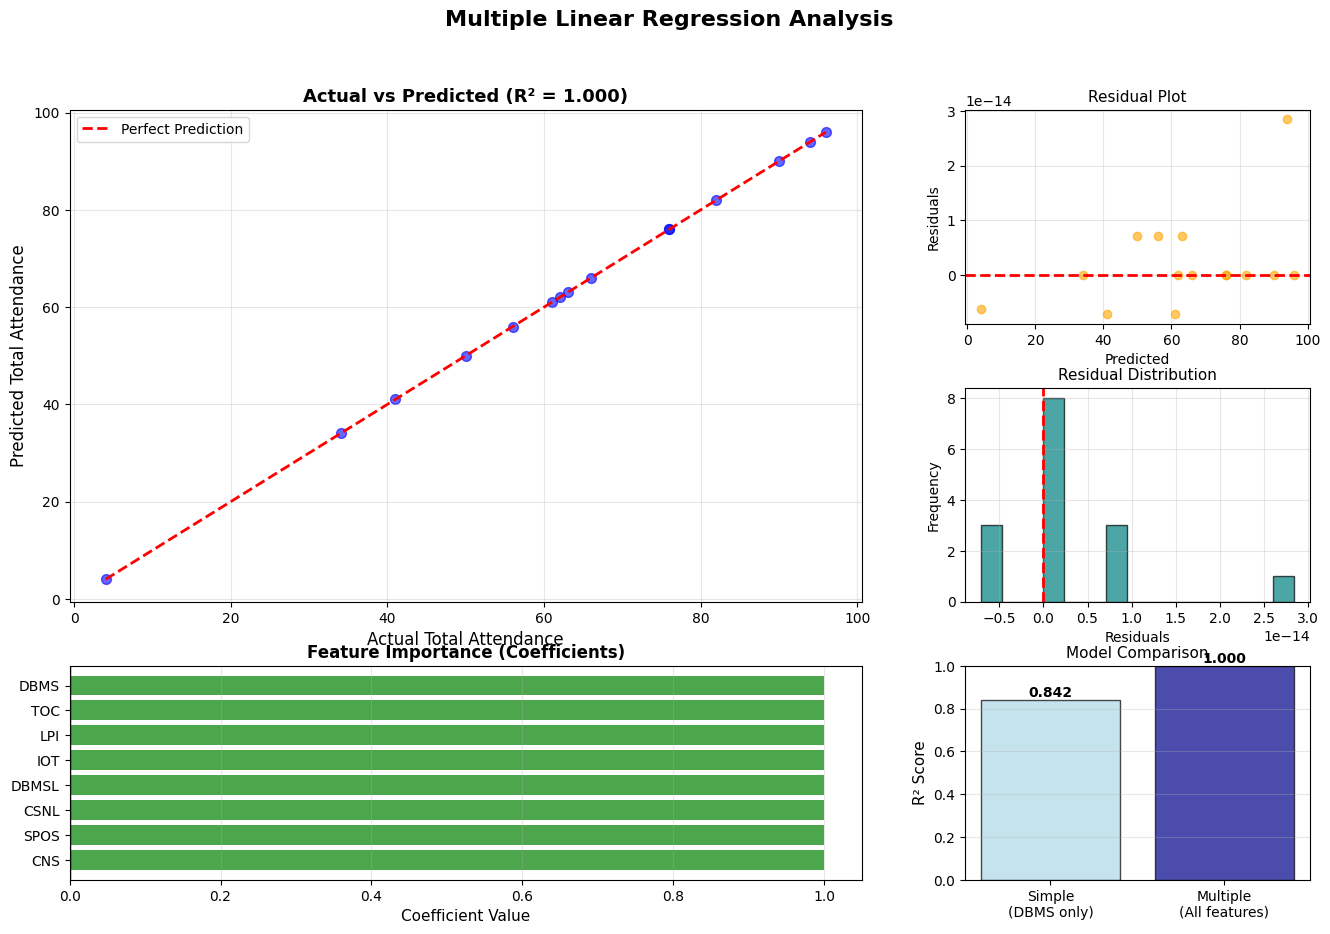

In [42]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Main title
fig.suptitle('Multiple Linear Regression Analysis', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted (large plot)
ax1 = fig.add_subplot(gs[0:2, 0:2])
ax1.scatter(y_test, y_test_pred, alpha=0.6, color='blue', s=50)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Total Attendance', fontsize=12)
ax1.set_ylabel('Predicted Total Attendance', fontsize=12)
ax1.set_title(f'Actual vs Predicted (R² = {r2_test:.3f})', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals
ax2 = fig.add_subplot(gs[0, 2])
residuals = y_test - y_test_pred
ax2.scatter(y_test_pred, residuals, alpha=0.6, color='orange')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted', fontsize=10)
ax2.set_ylabel('Residuals', fontsize=10)
ax2.set_title('Residual Plot', fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Residual distribution
ax3 = fig.add_subplot(gs[1, 2])
ax3.hist(residuals, bins=15, color='teal', alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Residuals', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.set_title('Residual Distribution', fontsize=11)
ax3.grid(True, alpha=0.3)

# Plot 4: Feature Importance
ax4 = fig.add_subplot(gs[2, :2])
colors_bar = ['green' if c > 0 else 'red' for c in feature_importance['Coefficient']]
ax4.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors_bar, alpha=0.7)
ax4.axvline(x=0, color='black', linewidth=1)
ax4.set_xlabel('Coefficient Value', fontsize=11)
ax4.set_title('Feature Importance (Coefficients)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# Plot 5: Model Comparison
ax5 = fig.add_subplot(gs[2, 2])
models = ['Simple\n(DBMS only)', 'Multiple\n(All features)']
r2_scores = [r2_simple, r2_test]
colors_comp = ['lightblue', 'darkblue']
bars = ax5.bar(models, r2_scores, color=colors_comp, alpha=0.7, edgecolor='black')
ax5.set_ylabel('R² Score', fontsize=11)
ax5.set_title('Model Comparison', fontsize=11)
ax5.set_ylim(0, 1)
ax5.grid(True, alpha=0.3, axis='y')
for bar, score in zip(bars, r2_scores):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.savefig('multiple_regression_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved as 'multiple_regression_analysis.png'")
plt.show()